/tmp/ipykernel_16461/1671218199.py:38: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  source["Measurement Time"] = pd.to_datetime(source["Measurement Time"])
/tmp/ipykernel_16461/1671218199.py:40: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  source = source.resample("24H").last()
/tmp/ipykernel_16461/1671218199.py:38: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  source["Measurement Time"] = pd.to_datetime(source["Measurement Time"])
/tmp/ipykernel_16461/1671218199.py:40: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  source = source.resample("24H").last()
/tmp/ipykernel_16461/1671218199.py:38: UserWarning

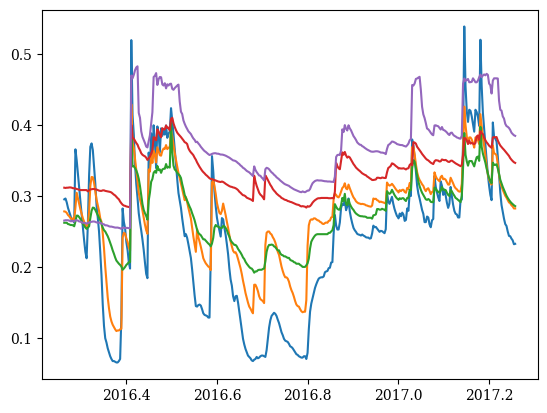

5


In [23]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from pathlib import Path
import os
import sys
import tensorflow as tf
tf.random.set_seed(42)
np.random.seed(42)
from pathlib import Path
home = Path.home()
subdir = home / "src" / "at-gpflow" / "experiments" / "soil-moisture" / "Wageningen" ## or whatever folder at-gpflow lives in
at_dir = home / "src" / "at-gpflow"


sys.path.append(str(at_dir))
sys.path.append(str(subdir))
BASE = str(subdir)

# Experiment 1: different substations using multiple depths
# station_indices = ["14", "14", "15", "15"]
# depths = [5, 10, 10, 20]
# substations = []

# Experiment 2: different substations at the same depth
# station_indices = [f"0{d}" for d in range(1, 6)]
# depths = [10 for d in range(1, 6)]
# substations = []

# # Experiment 3: same substation, different depths
station_indices = [f"15" for d in range(1, 6)]
depths = [5, 10, 20, 40, 80]

substations = []
for station, depth in zip(station_indices, depths):

    source = pd.read_csv(BASE+f"/data/station_data/RM_SM_{station}_calibrated.csv")
    source["Measurement Time"] = pd.to_datetime(source["Measurement Time"])
    source.index = source["Measurement Time"]
    source = source.resample("24H").last()

    source['decimal_year'] = source['Measurement Time'].dt.year + (source['Measurement Time'].dt.dayofyear - 1) / 365.25
    source.index = source["decimal_year"]
    substations.append(source)

    plt.plot(source.index, source[f"{depth} cm VWC [m3/m3]"])
plt.show()

print(len(substations))


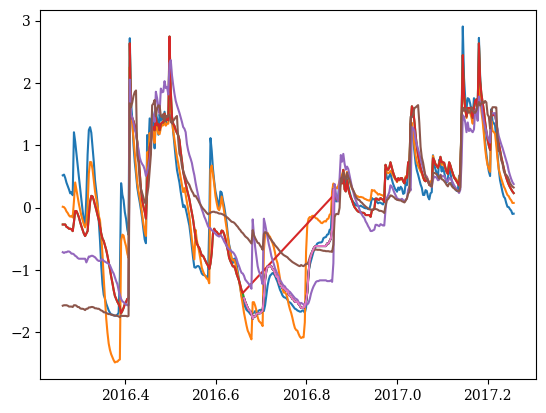

1752


In [24]:
condition_index = 2
data_X = []
data_Y = []

for i, (depth, data) in enumerate(zip(depths, substations)):
    Ay = data[f"{depth} cm VWC [m3/m3]"].to_numpy().reshape(-1, 1) 
    Ax = data.index.to_numpy().reshape(-1, 1)
    Ax = Ax[~np.isnan(Ay)].reshape(-1, 1)
    Ay = Ay[~np.isnan(Ay)].reshape(-1, 1)
    Ay = (Ay - Ay.mean()) / np.std(Ay)

    plt.plot(Ax, Ay)
    if i == condition_index:
        n_test = int(0.2*len(Ax))
        start = int(2*int(len(Ax))/5)
        end = start + n_test
        Xtest, ytest = Ax[start:end], Ay[start:end]
        Ax, Ay = np.concatenate((Ax[:start], Ax[end:])), np.concatenate((Ay[:start], Ay[end:]))
        plt.plot(Ax, Ay)
        plt.plot(Xtest, ytest, color="k")
    data_X.append(np.hstack((Ax, i*np.ones_like(Ax))))
    data_Y.append(np.hstack((Ay, i*np.ones_like(Ay))))

X = np.vstack(tuple(data_X))
y = np.vstack(tuple(data_Y))
plt.plot(Xtest, ytest)
plt.show()
print(len(X))

╒════════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤════════════════╕
│ name                                               │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value          │
╞════════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪════════════════╡
│ ConditionalMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0            │
├────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────────┤
│ ConditionalMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0            │
├────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────

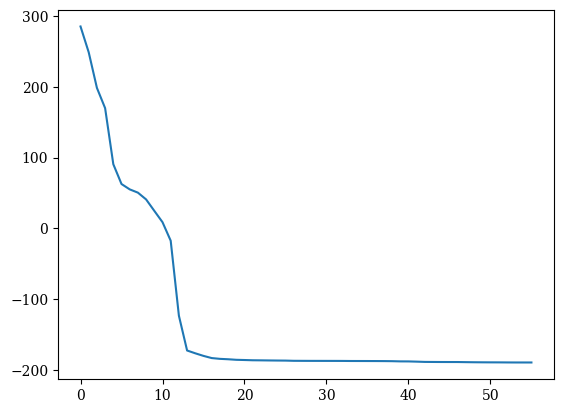

╒════════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════════════════════════════════╕
│ name                                               │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value                               │
╞════════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════════════════════════════════╡
│ ConditionalMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.4321721811013332                  │
├────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────────────────────────────────┤
│ ConditionalMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.017562328095569336          

In [25]:
from atmodel import SparseCMOGP, ConditionalMOGP
from atlikelihood import TransferLikelihood
import gpflow as gpf

def optimize(m):
    opt = gpf.optimizers.Scipy()
    res = opt.minimize(m.training_loss, m.trainable_variables, track_loss_history=True, options={"disp": 50})
    plt.plot(res["loss_history"])
    plt.show()

output_dim = len(substations) # Number of outputs
rank = 1 # Rank of W

# Base kernel
k = gpf.kernels.Matern32(active_dims=[0])

# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)

kern = k * coreg

model1 = ConditionalMOGP((X, y), kernel=kern, conditioning_index=condition_index, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))

gpf.utilities.print_summary(model1)
optimize(model1)
gpf.utilities.print_summary(model1)


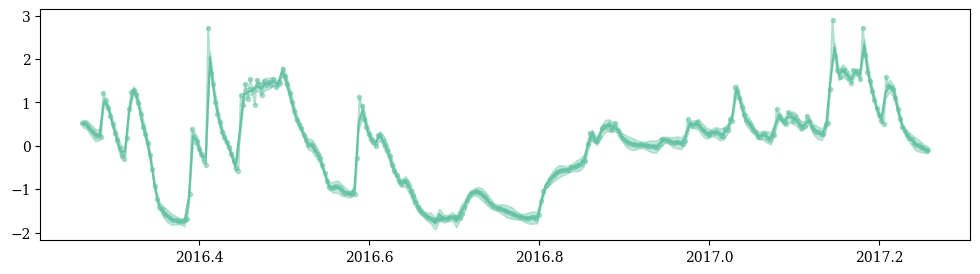

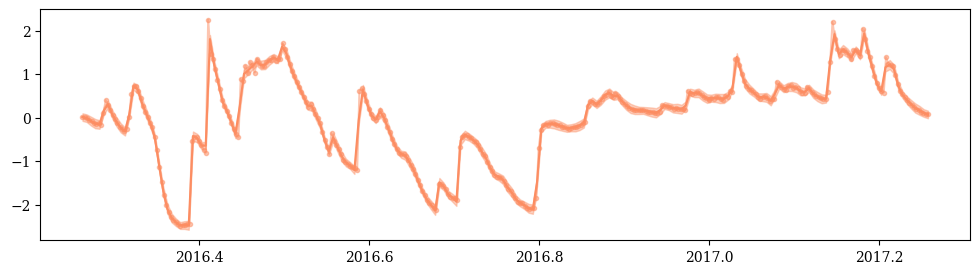

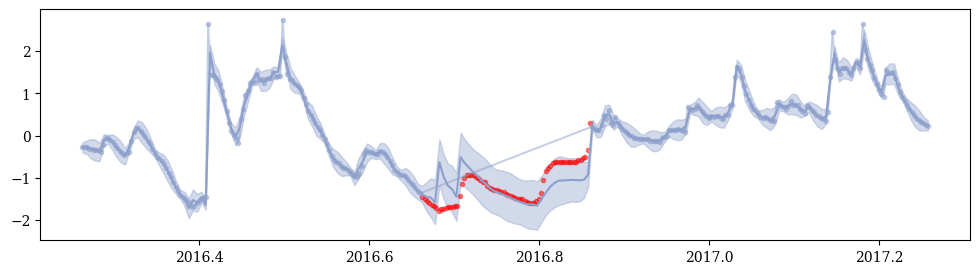

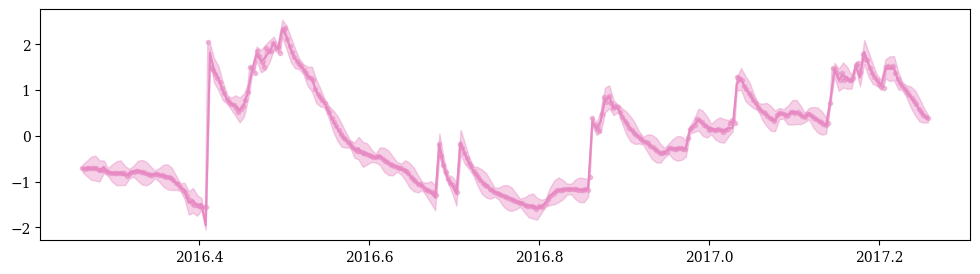

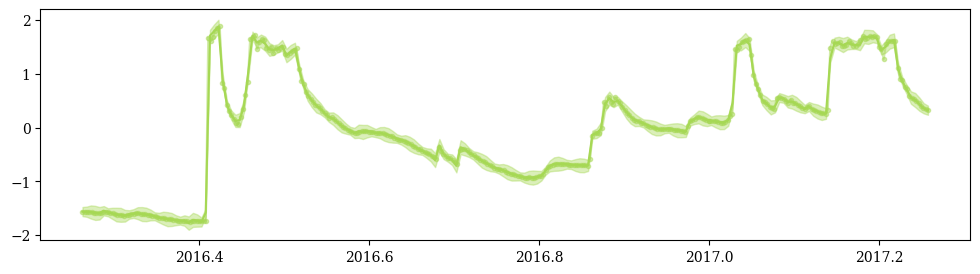

0.14865657215000333

In [26]:
from sklearn.metrics import mean_squared_error
from matplotlib import color_sequences
Xtst = Xtest.reshape(-1, 1)

colors = color_sequences["Set2"]
for index in range(output_dim):
    Ax, Ay = X[X[:,1] == index], y[y[:,1] == index]
    Xplot = np.hstack((np.linspace(min(X[:,0]), max(X[:,0]), 200)[:,None], index*np.ones((200, 1))))
    fmean, fvar = model1.predict_f(Xplot)
    plt.figure(figsize=(12, 3))
    if index == condition_index:  
       fmean_test, fvar_test = model1.predict_f(np.hstack((Xtest, index*np.ones((len(Xtest), 1)))))
       plt.plot(Xtest, ytest, "r.", alpha=0.5)
    plt.plot(Xplot[:,0], fmean, color=colors[index], label="source predictions")
    plt.plot(Ax[:,0], Ay[:,0], color=colors[index], marker=".", alpha=0.5, label="source")
    plt.fill_between(
        Xplot[:, 0],
        (fmean - 2 * np.sqrt(fvar))[:, 0],
        (fmean + 2 * np.sqrt(fvar))[:, 0],
        color=colors[index],
        alpha=0.4,
    )
plt.show()

ours_mse = mean_squared_error(ytest, fmean_test)
ours_mse

╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤════════════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value          │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪════════════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0            │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0            │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────────┤

2026-09-29 15:07:00.016242: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.
2026-09-29 15:07:00.020058: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.
2026-09-29 15:07:00.066347: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.
2026-09-29 15:07:00.070193: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.
2026-09-29 15:07:00.105942: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular out

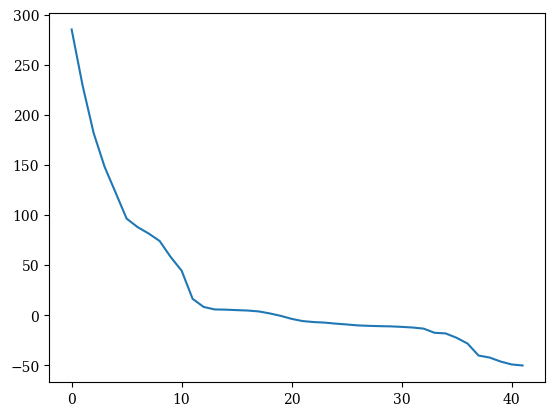

╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤════════════════════════════════════════════════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value                                              │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪════════════════════════════════════════════════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 6.2861                                             │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────────────────────────────────────────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │

In [27]:
from atmodel import SparseCMOGP, ConditionalMOGP
from atlikelihood import TransferLikelihood
import gpflow as gpf
from robust_svgp import LMCInducingVariable, LMCInducingPointsBase

def optimize(m):
    opt = gpf.optimizers.Scipy()
    res = opt.minimize(m.training_loss, m.trainable_variables, track_loss_history=True, options={"disp": 50})
    plt.plot(res["loss_history"])
    plt.show()

output_dim = len(substations) # Number of outputs
rank = 1 # Rank of W

# Base kernel
k = gpf.kernels.Matern32(active_dims=[0])

# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)
nIVS = 50 * output_dim
ivs = np.linspace(np.min(X[:,0]), np.max(X[:,0]), nIVS).reshape(-1, 1)
iv_ind = [j * np.ones((int(nIVS/output_dim), 1)) for j in range(output_dim)]
iv_ind = np.concatenate(iv_ind) 
shuffle = np.random.permutation(np.arange(len(ivs)))
ivs = ivs[shuffle]
ivs = np.hstack((ivs, iv_ind))

kern = k * coreg
#m = ConditionalMOGP((X, y), kernel=kern, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
model2 = SparseCMOGP((X, y), conditioning_index=condition_index, exact_target=False, kernel=kern, jitter=1e-5, inducing_variable=LMCInducingPointsBase(ivs), likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))


gpf.utilities.print_summary(model2)
optimize(model2)
gpf.utilities.print_summary(model2)

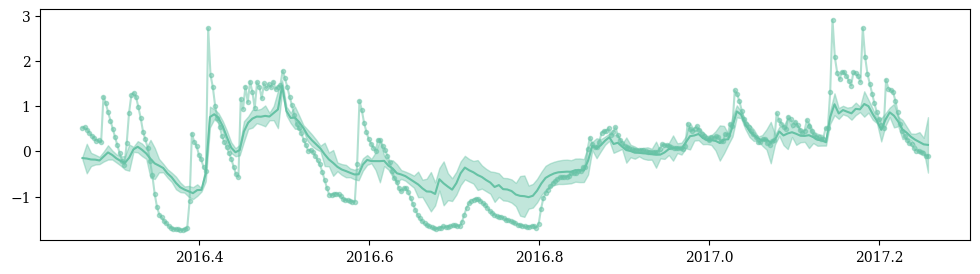

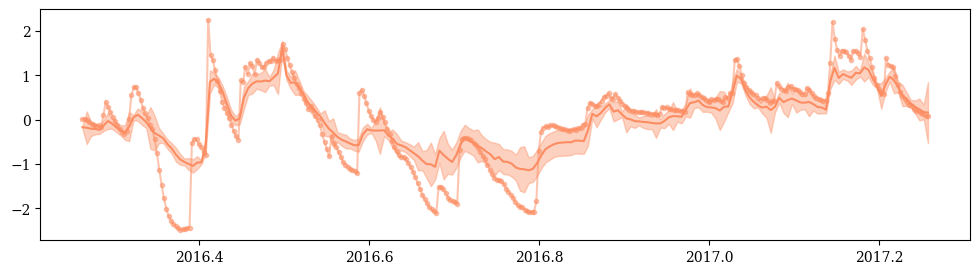

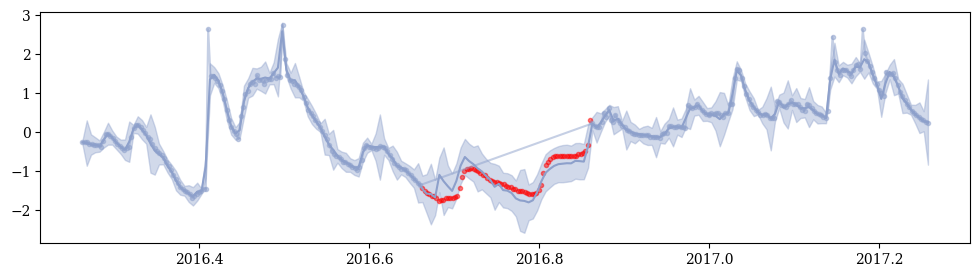

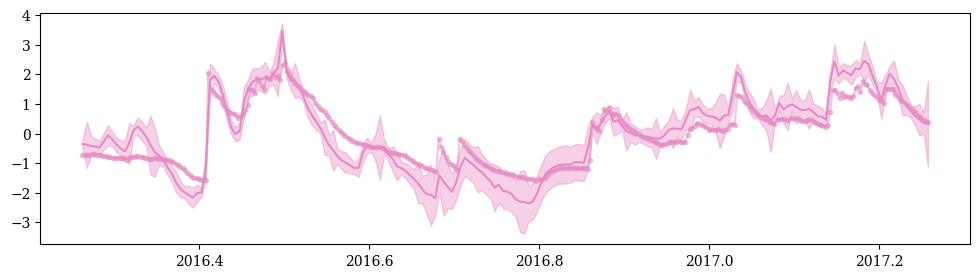

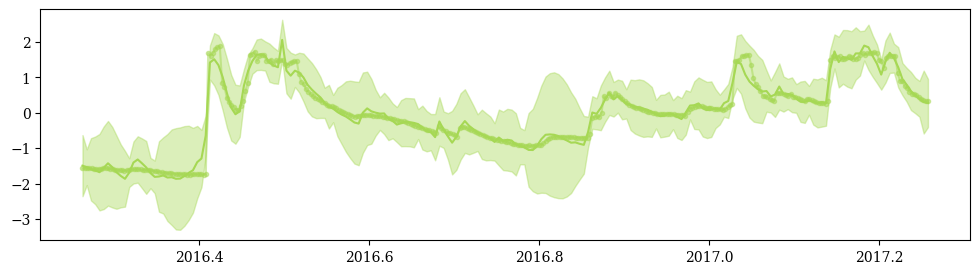

╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤════════════════════════════════════════════════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value                                              │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪════════════════════════════════════════════════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 6.2861                                             │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────────────────────────────────────────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │

0.05152866993467407

In [28]:
from sklearn.metrics import mean_squared_error
from matplotlib import color_sequences
Xtst = Xtest.reshape(-1, 1)
colors = color_sequences["Set2"]
for index in range(output_dim):
    Ax, Ay = X[X[:,1] == index], y[y[:,1] == index]
    Xplot = np.hstack((np.linspace(min(X[:,0]), max(X[:,0]), 200)[:,None], index*np.ones((200, 1))))
    fmean, fvar = model2.predict_f(Xplot)
    plt.figure(figsize=(12, 3))
    if index == condition_index:  
       fmean_test, fvar_test = model2.predict_f(np.hstack((Xtest, index*np.ones((len(Xtest), 1)))))
       plt.plot(Xtest, ytest, "r.", alpha=0.5)
    plt.plot(Xplot[:,0], fmean, color=colors[index], label="source predictions")
    plt.plot(Ax[:,0], Ay[:,0], color=colors[index], marker=".", alpha=0.5, label="source")
    plt.fill_between(
        Xplot[:, 0],
        (fmean - 2 * np.sqrt(fvar))[:, 0],
        (fmean + 2 * np.sqrt(fvar))[:, 0],
        color=colors[index],
        alpha=0.4,
    )
plt.show()
gpf.utilities.print_summary(model2)

ours_mse = mean_squared_error(ytest, fmean_test)
ours_mse

In [29]:
print(len(X))

1752


In [30]:
from atmodel import SparseCMOGP, ConditionalMOGP
from atlikelihood import TransferLikelihood
import gpflow as gpf
from robust_svgp import LMCInducingVariable, LMCInducingPointsBase

def optimize(m):
    opt = gpf.optimizers.Scipy()
    res = opt.minimize(m.training_loss, m.trainable_variables, track_loss_history=True, options={"disp": 50})
    plt.plot(res["loss_history"])
    plt.show()

output_dim = len(substations) # Number of outputs
rank = 1 # Rank of W

# Base kernel
k = gpf.kernels.Matern32(active_dims=[0])

# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)

kern = k * coreg
nIVS = 50 * output_dim
ivs = np.linspace(np.min(X[:,0]), np.max(X[:,0]), nIVS).reshape(-1, 1)
iv_ind = [j * np.ones((int(nIVS/output_dim), 1)) for j in range(output_dim)]
iv_ind = np.concatenate(iv_ind)  # I guess the IPs for the target don't matter here, but this makes the comparison fair.
shuffle = np.random.permutation(np.arange(len(ivs)))
ivs = ivs[shuffle]
ivs = np.hstack((ivs, iv_ind))

l1 = gpf.likelihoods.Gaussian()
l2 = gpf.likelihoods.Gaussian()
lik = gpf.likelihoods.SwitchedLikelihood(
    [l1 if i != condition_index else l2 for i in range(output_dim)]
)

# now build the GP model as normal
model3 =  gpf.models.SVGP(kernel=kern, likelihood=lik, num_data=len(X), inducing_variable=LMCInducingPointsBase(ivs))


gpf.utilities.print_summary(model3)
# fit the covariance function parameters
gpf.optimizers.Scipy().minimize(
    model3.training_loss_closure((X, y)),
    model3.trainable_variables,
    method="L-BFGS-B",
)
gpf.utilities.print_summary(model3)

╒═════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═══════════════╤═════════╤══════════════════╕
│ name                                    │ class     │ transform        │ prior   │ trainable   │ shape         │ dtype   │ value            │
╞═════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═══════════════╪═════════╪══════════════════╡
│ SVGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()            │ float64 │ 1.0              │
├─────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼───────────────┼─────────┼──────────────────┤
│ SVGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()            │ float64 │ 1.0              │
├─────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼───────────────┼─────────┼────────────

2026-09-29 15:07:03.128852: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/diag_part_grad/diag/diag_part/k' with dtype int32
	 [[{{node gradients/diag_part_grad/diag/diag_part/k}}]]
2026-09-29 15:07:03.226707: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad/ReverseV2/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2/axis' with dtype int32 and shape [1]
	 [[{{node gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad

╒═════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═══════════════╤═════════╤══════════════════════════════════════════════════════╕
│ name                                    │ class     │ transform        │ prior   │ trainable   │ shape         │ dtype   │ value                                                │
╞═════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═══════════════╪═════════╪══════════════════════════════════════════════════════╡
│ SVGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()            │ float64 │ 0.27036404532461                                     │
├─────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼───────────────┼─────────┼──────────────────────────────────────────────────────┤
│ SVGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ (

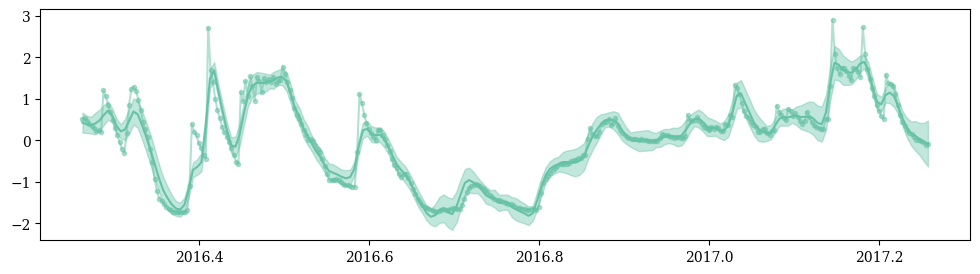

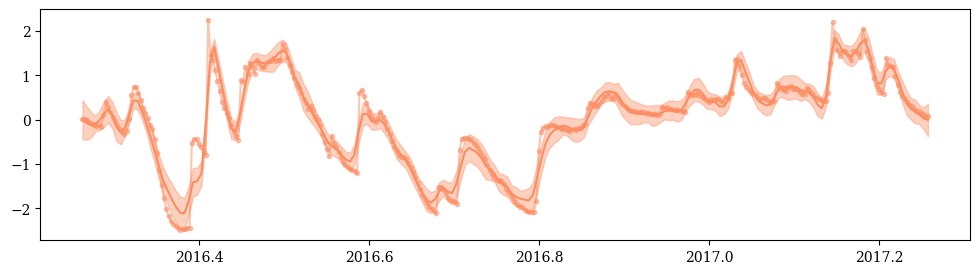

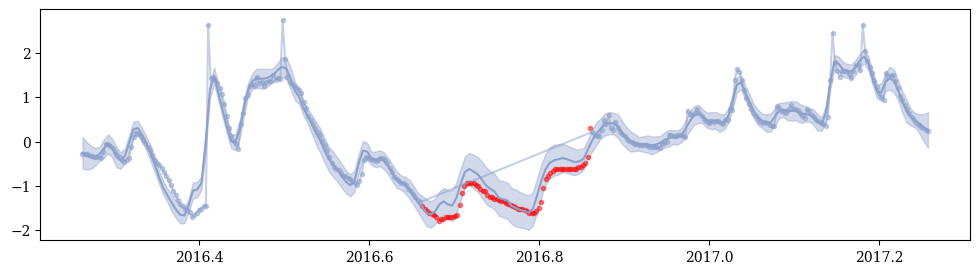

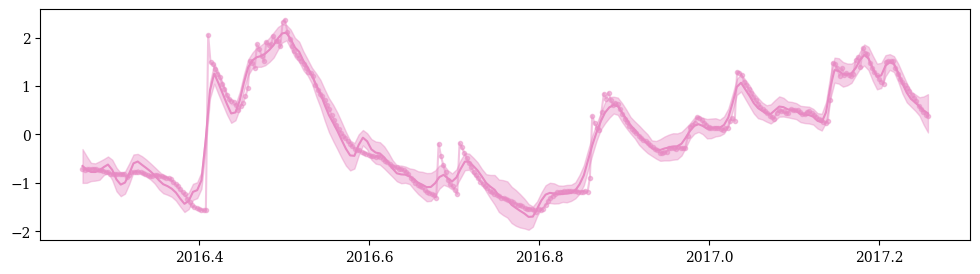

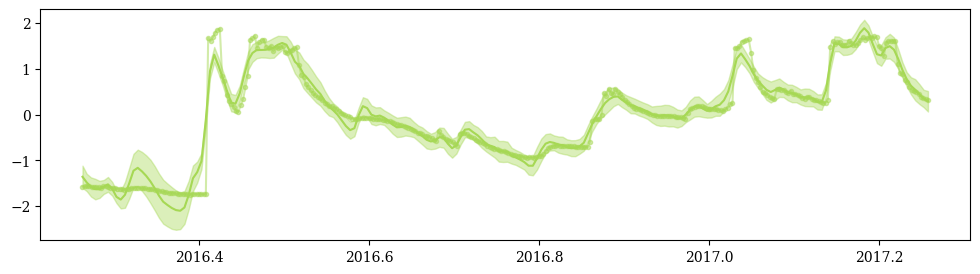

tf.Tensor(
[[-1.48975929]
 [-1.55530371]
 [-1.61863301]
 [-1.65204368]
 [-1.63819394]
 [-1.60092932]
 [-1.53814972]
 [-1.44898521]
 [-1.36718036]
 [-1.34641637]
 [-1.38759429]
 [-1.41923954]
 [-1.44284981]
 [-1.43910546]
 [-1.35449806]
 [-1.21526496]
 [-1.0472859 ]
 [-0.86593461]
 [-0.71794887]
 [-0.63414695]
 [-0.61689483]
 [-0.6393208 ]
 [-0.67436407]
 [-0.70821645]
 [-0.75007082]
 [-0.81061   ]
 [-0.88868858]
 [-0.9656005 ]
 [-1.02820446]
 [-1.06461199]
 [-1.07526357]
 [-1.12413745]
 [-1.2142487 ]
 [-1.2782347 ]
 [-1.30204627]
 [-1.30153481]
 [-1.30913731]
 [-1.35867808]
 [-1.4296355 ]
 [-1.47880267]
 [-1.49973782]
 [-1.51547201]
 [-1.54139872]
 [-1.55767502]
 [-1.56941636]
 [-1.58765897]
 [-1.6051548 ]
 [-1.56956033]
 [-1.45269435]
 [-1.27815591]
 [-1.08962643]
 [-0.91000444]
 [-0.7440706 ]
 [-0.61635005]
 [-0.5293437 ]
 [-0.46952923]
 [-0.4345989 ]
 [-0.4169283 ]
 [-0.40585879]
 [-0.39361261]
 [-0.37712719]
 [-0.36829496]
 [-0.39216029]
 [-0.42098107]
 [-0.43793671]
 [-0.46046722]

0.04906624379849936

In [31]:
from sklearn.metrics import mean_squared_error
from matplotlib import color_sequences
Xtst = Xtest.reshape(-1, 1)

colors = color_sequences["Set2"]
for index in range(output_dim):
    Ax, Ay = X[X[:,1] == index], y[y[:,1] == index]
    Xplot = np.hstack((np.linspace(min(X[:,0]), max(X[:,0]), 200)[:,None], index*np.ones((200, 1))))
    fmean, fvar = model3.predict_f(Xplot)
    plt.figure(figsize=(12, 3))
    if index == condition_index:  
       fmean_test, fvar_test = model3.predict_f(np.hstack((Xtest, index*np.ones((len(Xtest), 1)))))
       plt.plot(Xtest, ytest, "r.", alpha=0.5)
    plt.plot(Xplot[:,0], fmean, color=colors[index], label="source predictions")
    plt.plot(Ax[:,0], Ay[:,0], color=colors[index], marker=".", alpha=0.5, label="source")
    plt.fill_between(
        Xplot[:, 0],
        (fmean - 2 * np.sqrt(fvar))[:, 0],
        (fmean + 2 * np.sqrt(fvar))[:, 0],
        color=colors[index],
        alpha=0.4,
    )
plt.show()

print(fmean_test)
ours_mse = mean_squared_error(ytest, fmean_test[:,0])
ours_mse

In [32]:
from atmodel import SparseCMOGP, ConditionalMOGP
from atlikelihood import TransferLikelihood
import gpflow as gpf
from robust_svgp import LMCInducingVariable, LMCInducingPointsBase

def optimize(m):
    opt = gpf.optimizers.Scipy()
    res = opt.minimize(m.training_loss, m.trainable_variables, track_loss_history=True, options={"disp": 50})
    plt.plot(res["loss_history"])
    plt.show()

output_dim = len(substations) # Number of outputs
rank = 1 # Rank of W

# Base kernel
k = gpf.kernels.Matern32(active_dims=[0])

# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)
nIVS = 50 * 1
shuffle = np.random.permutation(nIVS)
ivs = np.linspace(np.min(X[:,0]), np.max(X[:,0]), nIVS).reshape(-1, 1)
ivs = ivs[shuffle]

l1 = gpf.likelihoods.Gaussian()
l2 = gpf.likelihoods.Gaussian()
lik = gpf.likelihoods.SwitchedLikelihood(
    [l1 if i != condition_index else l2 for i in range(output_dim)]
)

Xt, yt = X[X[:,1] == condition_index][:,0][:,None], y[y[:,1] == condition_index][:,0][:,None]
# now build the GP model as normal
model4 =  gpf.models.SGPR((Xt, yt), kernel=k, likelihood=l1, inducing_variable=ivs[:,0][:,None])


gpf.utilities.print_summary(model4)
# fit the covariance function parameters
gpf.optimizers.Scipy().minimize(
    model4.training_loss,
    model4.trainable_variables,
    method="L-BFGS-B",
)
gpf.utilities.print_summary(model4)

╒══════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════════════╕
│ name                     │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value           │
╞══════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════════════╡
│ SGPR.kernel.variance     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0             │
├──────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────────────┤
│ SGPR.kernel.lengthscales │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0             │
├──────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────────────┤
│ SGPR.likelihood.variance │ Parameter │ Softplus + Shift │         │ True        │ ()      │ float64 │ 1.0             │
├───────────────────────

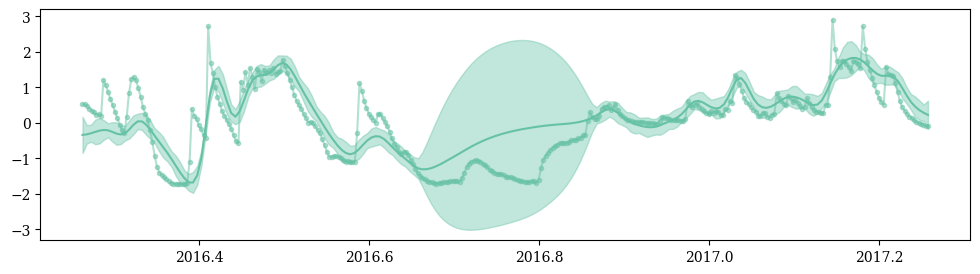

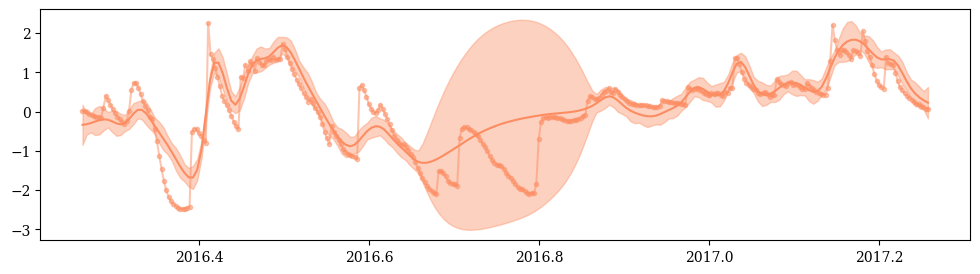

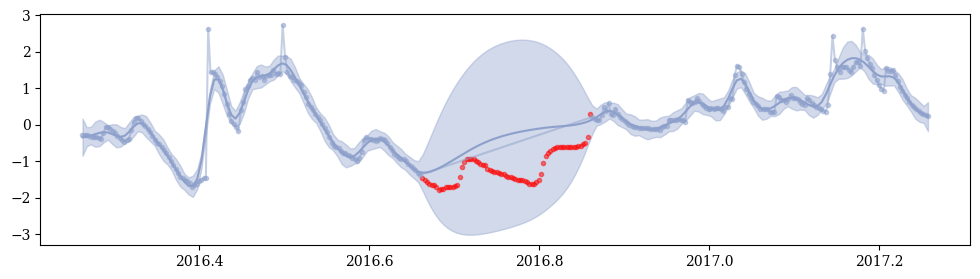

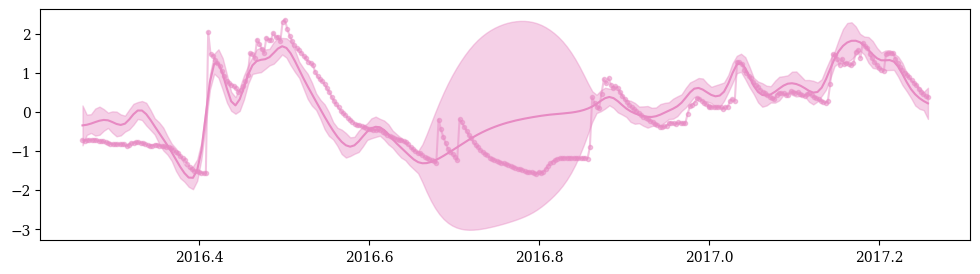

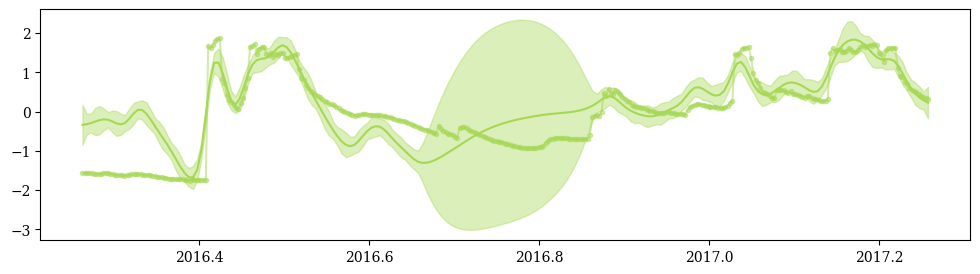

tf.Tensor(
[[-1.30858476]
 [-1.31017699]
 [-1.3036934 ]
 [-1.29043682]
 [-1.27154636]
 [-1.24801836]
 [-1.22071477]
 [-1.19037883]
 [-1.15765015]
 [-1.12307181]
 [-1.08710102]
 [-1.05011906]
 [-1.01243623]
 [-0.97429848]
 [-0.93589405]
 [-0.8973574 ]
 [-0.85877385]
 [-0.82021674]
 [-0.78190791]
 [-0.74409249]
 [-0.70698279]
 [-0.67076191]
 [-0.63559074]
 [-0.60161069]
 [-0.5689471 ]
 [-0.53770929]
 [-0.50792287]
 [-0.47954642]
 [-0.45253045]
 [-0.42682088]
 [-0.40235914]
 [-0.37908253]
 [-0.35692457]
 [-0.33582637]
 [-0.31575905]
 [-0.29669701]
 [-0.27861345]
 [-0.26148039]
 [-0.245269  ]
 [-0.22994998]
 [-0.21549232]
 [-0.20183608]
 [-0.18890262]
 [-0.17661361]
 [-0.16488931]
 [-0.15364986]
 [-0.14281341]
 [-0.13229649]
 [-0.12205493]
 [-0.11213624]
 [-0.10260036]
 [-0.09350645]
 [-0.08491437]
 [-0.07688655]
 [-0.06948996]
 [-0.06279574]
 [-0.05680707]
 [-0.05134806]
 [-0.046218  ]
 [-0.04121889]
 [-0.03615447]
 [-0.03081918]
 [-0.02500835]
 [-0.01850638]
 [-0.01108555]
 [-0.0025033 ]

0.6829708539467392

In [33]:
from sklearn.metrics import mean_squared_error
from matplotlib import color_sequences
Xtst = Xtest.reshape(-1, 1)

colors = color_sequences["Set2"]
for index in range(output_dim):
    Ax, Ay = X[X[:,1] == index], y[y[:,1] == index]
    Xplot = np.hstack((np.linspace(min(X[:,0]), max(X[:,0]), 200)[:,None], index*np.ones((200, 1))))
    fmean, fvar = model4.predict_f(Xplot[:,0][:,None])
    plt.figure(figsize=(12, 3))
    if index == condition_index:  
       fmean_test, fvar_test = model4.predict_f(Xtest)
       plt.plot(Xtest, ytest, "r.", alpha=0.5)
    plt.plot(Xplot[:,0], fmean, color=colors[index], label="source predictions")
    plt.plot(Ax[:,0], Ay[:,0], color=colors[index], marker=".", alpha=0.5, label="source")
    plt.fill_between(
        Xplot[:, 0],
        (fmean - 2 * np.sqrt(fvar))[:, 0],
        (fmean + 2 * np.sqrt(fvar))[:, 0],
        color=colors[index],
        alpha=0.4,
    )
plt.show()

print(fmean_test)
ours_mse = mean_squared_error(ytest, fmean_test[:,0])
ours_mse

╒════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤══════════╤═════════╤═════════════════════════════════════╕
│ name                                   │ class     │ transform        │ prior   │ trainable   │ shape    │ dtype   │ value                               │
╞════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪══════════╪═════════╪═════════════════════════════════════╡
│ GPRFITC.kernel.kernels[0].variance     │ Parameter │ Softplus         │         │ True        │ ()       │ float64 │ 1.0                                 │
├────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼──────────┼─────────┼─────────────────────────────────────┤
│ GPRFITC.kernel.kernels[0].lengthscales │ Parameter │ Softplus         │         │ True        │ ()       │ float64 │ 1.0                                 │
├────────────────────────────────────────┼───────────┼────

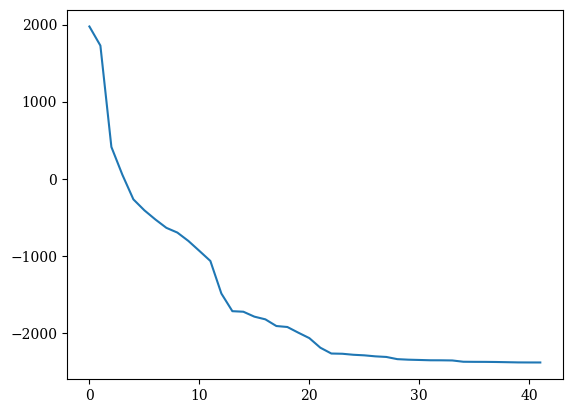

In [34]:
def optimize(m):
    opt = gpf.optimizers.Scipy()
    res = opt.minimize(m.training_loss, m.trainable_variables, track_loss_history=True, options={"disp": 50})
    plt.plot(res["loss_history"])
    plt.show()

output_dim = len(substations) # Number of outputs
rank = 1 # Rank of W

# Base kernel
k = gpf.kernels.Matern32(active_dims=[0])

# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)
nIVS = 50 * output_dim
ivs = np.linspace(np.min(X[:,0]), np.max(X[:,0]), nIVS).reshape(-1, 1)
iv_ind = [j * np.ones((int(nIVS/output_dim), 1)) for j in range(output_dim)]
iv_ind = np.concatenate(iv_ind)  # I guess the IPs for the target don't matter here, but this makes the comparison fair.
shuffle = np.random.permutation(np.arange(len(ivs)))
ivs = ivs[shuffle]
ivs = np.hstack((ivs, iv_ind))

l1 = gpf.likelihoods.Gaussian()

kern = k * coreg
# now build the GP model as normal
model5 =  gpf.models.GPRFITC((X, y), kernel=kern, likelihood=l1, inducing_variable=ivs)


gpf.utilities.print_summary(model5)
# fit the covariance function parameters
optimize(model5)

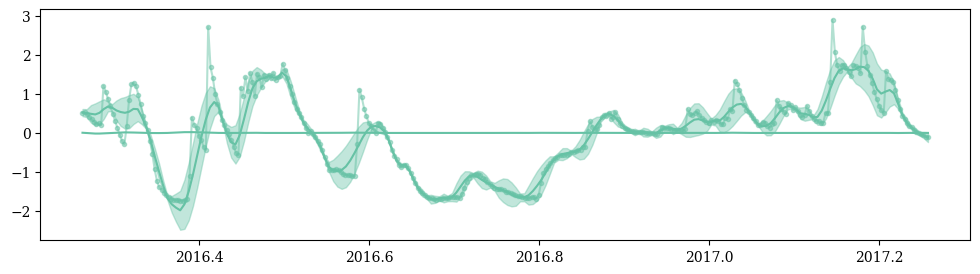

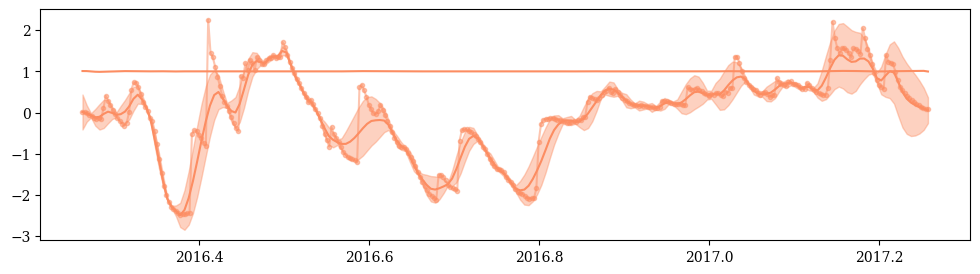

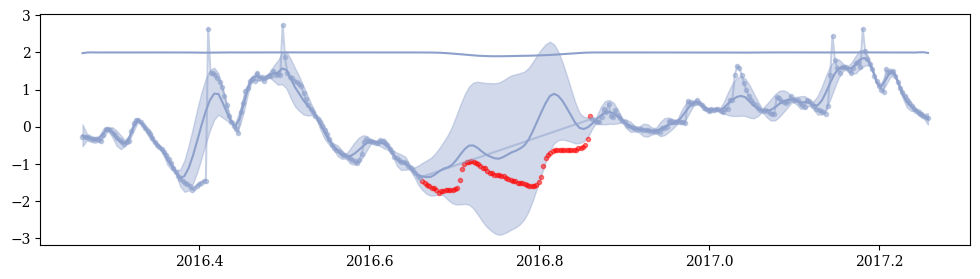

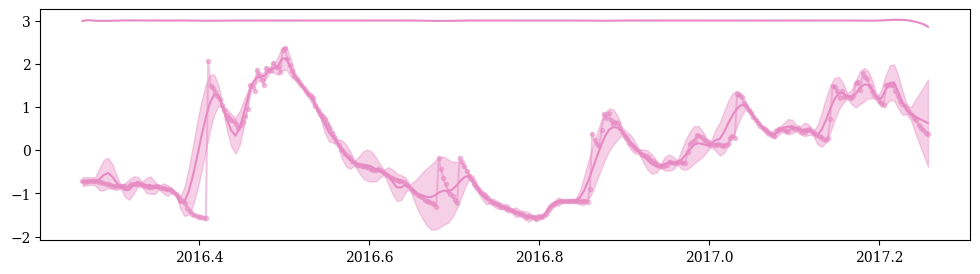

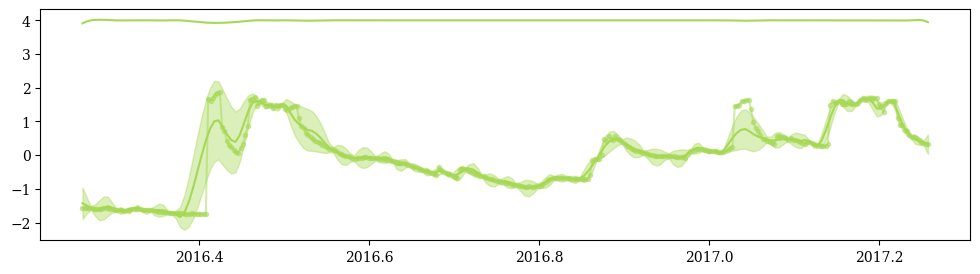

tf.Tensor(
[[-1.3388032   1.99975366]
 [-1.35285491  1.9994786 ]
 [-1.36063876  1.99909913]
 [-1.35880357  1.99857609]
 [-1.34263421  1.99779545]
 [-1.30851827  1.99663736]
 [-1.2621253   1.99505583]
 [-1.2124736   1.99302464]
 [-1.16760119  1.99046237]
 [-1.13338733  1.98720625]
 [-1.11274909  1.9833149 ]
 [-1.09455349  1.97900982]
 [-1.06415615  1.97445353]
 [-1.0137674   1.96961465]
 [-0.94567249  1.96449254]
 [-0.86601065  1.95917364]
 [-0.78101837  1.95372872]
 [-0.69685062  1.94821286]
 [-0.61962547  1.94266793]
 [-0.55555119  1.93711966]
 [-0.51146583  1.93158375]
 [-0.49496067  1.92608341]
 [-0.50623425  1.92080789]
 [-0.53850634  1.91599635]
 [-0.58448177  1.9117833 ]
 [-0.63702699  1.90827783]
 [-0.68938474  1.90536699]
 [-0.73570435  1.90285321]
 [-0.7716335   1.90073488]
 [-0.79971399  1.89904617]
 [-0.82517729  1.89782337]
 [-0.84935687  1.89710621]
 [-0.86436577  1.89688686]
 [-0.86139294  1.89711778]
 [-0.84040415  1.89768296]
 [-0.8094166   1.89847986]
 [-0.77572272  1.

0.7907041053279069

In [35]:
from sklearn.metrics import mean_squared_error
from matplotlib import color_sequences
Xtst = Xtest.reshape(-1, 1)

colors = color_sequences["Set2"]
for index in range(output_dim):
    Ax, Ay = X[X[:,1] == index], y[y[:,1] == index]
    Xplot = np.hstack((np.linspace(min(X[:,0]), max(X[:,0]), 200)[:,None], index*np.ones((200, 1))))
    fmean, fvar = model5.predict_f(Xplot)
    plt.figure(figsize=(12, 3))
    if index == condition_index:  
       fmean_test, fvar_test = model5.predict_f(np.hstack((Xtest, index*np.ones((len(Xtest), 1)))))
       plt.plot(Xtest, ytest, "r.", alpha=0.5)
    plt.plot(Xplot[:,0], fmean, color=colors[index], label="source predictions")
    plt.plot(Ax[:,0], Ay[:,0], color=colors[index], marker=".", alpha=0.5, label="source")
    plt.fill_between(
        Xplot[:, 0],
        (fmean - 2 * np.sqrt(fvar))[:, 0],
        (fmean + 2 * np.sqrt(fvar))[:, 0],
        color=colors[index],
        alpha=0.4,
    )
plt.show()

print(fmean_test)
ours_mse = mean_squared_error(ytest, fmean_test[:,0])
ours_mse

CMOGP 0.14865657215000333
sCMOGP 0.05152866993467407
SVGP 0.04906624379849936
GPFITC 0.7907041053279069


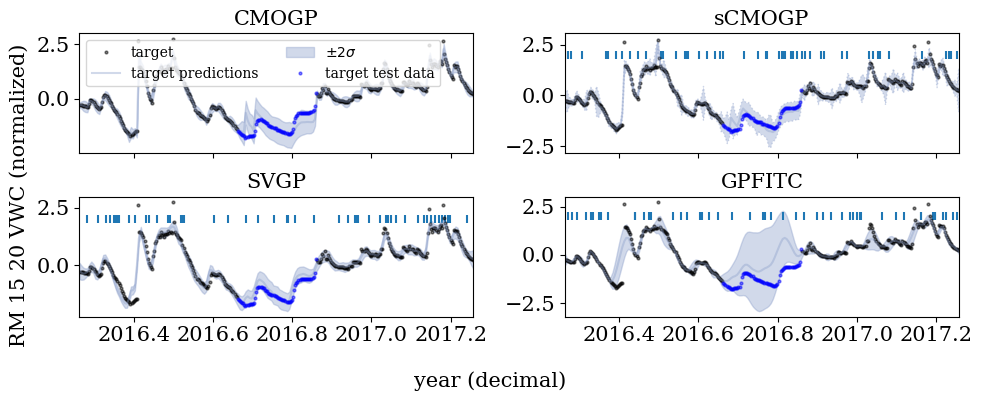

In [38]:
colors = color_sequences["Set2"]
plt.rcParams["font.family"] = "serif"
names = ["CMOGP", "sCMOGP", "SVGP", "GPFITC"]
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10, 4), sharex=True)
for i, (model, ax) in enumerate(zip([model1, model2, model3, model5], [ax1, ax2, ax3, ax4])):
    for index in [condition_index]:
        Ax, Ay = X[X[:,1] == index], y[y[:,1] == index]
        Xplot = np.hstack((np.linspace(min(X[:,0]), max(X[:,0]), 200)[:,None], index*np.ones((200, 1))))
        fmean, fvar = model.predict_f(Xplot)
        ymean, yvar = model.predict_y(Xplot)
        fmean_test, fvar_test = model.predict_f(np.hstack((Xtest, index*np.ones((len(Xtest), 1)))))
        ymean_test, yvar_test = model.predict_y(np.hstack((Xtest, index*np.ones((len(Xtest), 1)))))
        ax.plot(Ax[:,0], Ay[:,0], color="k", marker=".", lw=0, ms=4, alpha=0.5, label=f"target")
        for j, (mean, var) in enumerate([(fmean, fvar)]):
            ax.plot(Xplot[:,0], mean[:,0], color=colors[index], alpha=0.4, label=f"target predictions")
            ax.fill_between(
                Xplot[:, 0],
                (mean[:,0] - 2 * np.sqrt(var)[:, 0]),
                (mean[:,0] + 2 * np.sqrt(var)[:, 0]),
                color=colors[index],
                alpha=0.4,
                label="$\pm 2\sigma$",
                linestyle=":" if i == 1 else "-"
            )
        ax.set_xlim(np.min(Ax[:,0]), np.max(Ax[:,0]))
        ax.set_title(names[i], fontsize=15)
        fig.supxlabel("year (decimal)", fontsize=15)
        fig.supylabel(f"RM {station_indices[condition_index]} {depths[condition_index]} VWC (normalized)", fontsize=15)
        ax.tick_params(axis="both", labelsize=15)
        ax.plot(Xtest, ytest, "b.", ms=4, alpha=0.5, label="target test data")
        if i > 0: 
            ivs = model.inducing_variable.Z.numpy()
            ivs_target = ivs[ivs[:,1] == condition_index]
            ax.scatter(ivs_target, 2*np.ones_like(ivs_target), marker="|", label="inducing variables") 
        if i == 0:
            ax.legend(ncols=2)

        Xt, yt = X[X[:,1] == condition_index], y[y[:,1] == condition_index]
        ymean_nce, yvar_nce = model.predict_f(np.hstack((Xtest, index*np.ones((len(Xtest), 1)))) if names[i] != "SGPR" else model.predict_y(Xtest) )
        mse = mean_squared_error(ytest, fmean_test[:,0])
        print(names[i], mse)
plt.tight_layout()
plt.show()

In [37]:
np.logspace(6, 14, 8, base=2)

array([   64.        ,   141.32345775,   312.06749548,   689.10089863,
        1521.65815208,  3360.09361821,  7419.68825765, 16384.        ])